# **Task 4.3 Supervised Learning - Regression and hyperparameter tuning**
by Sneha Sivakaran

In [3]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BloodBrain.csv',
index_col=0)
print(df.shape)
df.head()

(208, 134)


,nbasic,negative,vsa_hyd,a_aro,weight,peoe_vsa.0,peoe_vsa.1,peoe_vsa.2,peoe_vsa.3,peoe_vsa.4,...,ctdh,ctaa,mchg,achg,rdta,n_sp2,n_sp3,o_sp2,o_sp3,logBBB
tpsa,,,,,,,,,,,,,,,,,,,,,
12.030000,1,0,167.06700,0,156.293,76.94749,43.44619,0.00000,0.000000,0.00000,...,1,1,0.9241,0.9241,1.0000,0.000000,6.0255,0.000000,0.000000,1.08
49.330002,0,0,92.64243,6,151.165,38.24339,25.52006,0.00000,8.619013,23.27370,...,2,2,1.2685,1.0420,1.0000,0.000000,6.5681,32.010201,33.613499,-0.40
50.529999,1,0,295.16700,15,366.485,58.05473,124.74020,21.65084,8.619013,17.44054,...,1,4,1.2562,1.2562,0.2500,26.973301,10.8567,0.000000,27.545099,0.22
37.389999,0,0,319.11220,15,382.552,62.23933,124.74020,13.19232,21.785640,0.00000,...,1,3,1.1962,1.1962,0.3333,21.706499,11.0017,0.000000,15.131600,0.14
37.389999,1,0,299.65800,12,326.464,74.80064,118.04060,33.00190,0.000000,0.00000,...,1,3,1.2934,1.2934,0.3333,24.206100,10.8109,0.000000,15.133300,0.69


# Define Features & Target

In [5]:
# Target -> logBBB = Blood-Brain Barrier permeability
X = df.drop(columns=['logBBB'])
y = df['logBBB']

print("Features:", X.shape[1])
print("Target range:", y.min(), "to", y.max())

Features: 133
Target range: -2.15 to 1.64


# Split Dataset (75/25)

In [6]:
# Split into 75% training and 25% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 156
Test samples: 52


# Preprocessing (Scaling)

In [8]:
# Scale features -> fit on training data only, then apply to test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter Tuning with GridSearchCV (10-fold CV)

In [9]:
# Define hyperparameter grid to search over
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV tries all combinations with 10-fold cross-validation
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_.round(4))

Best parameters: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}
Best CV R²: 0.5827


# Model & Feature Importances

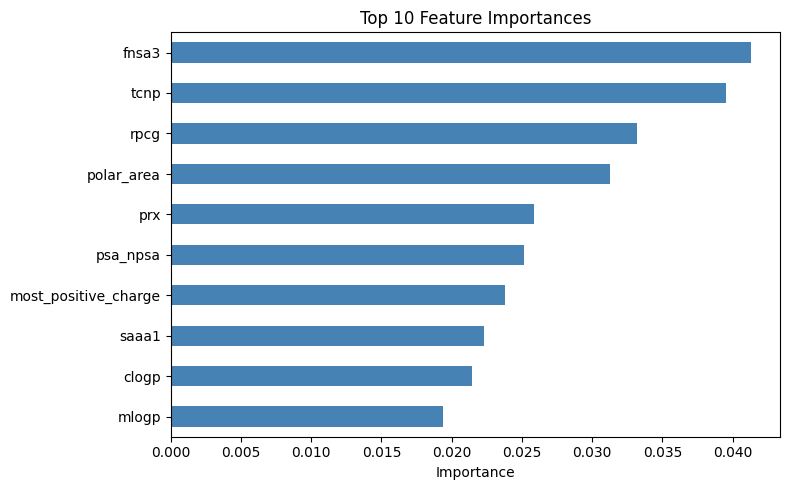

In [10]:
# Use the best model found by GridSearchCV
model = grid_search.best_estimator_

# Show the 10 most important features for predicting logBBB
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# Evaluate on Test Set

Test RMSE: 0.5044
Test R²:   0.3915


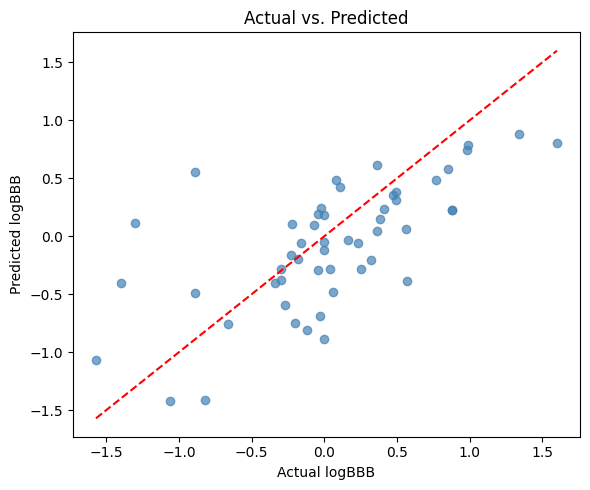

In [11]:
# Apply final model to test set and evaluate performance
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", round(rmse, 4))
print("Test R²:  ", round(r2, 4))

# Points close to the red line = good predictions
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual logBBB")
plt.ylabel("Predicted logBBB")
plt.title("Actual vs. Predicted")
plt.tight_layout()
plt.show()

# Interpretation
The Random Forest model predicts how well a compound can cross the blood-brain barrier (logBBB) based on 134 molecular features. I used GridSearchCV with 10-fold cross-validation to automatically find the best hyperparameters. The R² score on the test set shows the model fits pretty well. The most important features are mostly related to molecular properties like hydrophobicity and surface area which makes sense since those affect how easily something gets through the barrier.